Look at figure box overall stats.

This assumes you have already run `inject_figures_batch.py`

This is *just* for the working on subpanel distribution, not taking a gander at stats generally.

In [1]:
#save_json_dir = '/Users/jnaiman/Dropbox/wwt_image_extraction/FullProcess_resources/arxiv_test_jsons/' # small test
save_json_dir = '/Users/jnaiman/Dropbox/wwt_image_extraction/FullProcess_resources/arxiv_new_jsons/' # larger test

# base arxiv dir?
arxiv_dir = '/Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/'

# save tmp files
tmp_dir = '/Users/jnaiman/Downloads/tmp/tiff_files/'


In [2]:
# debug
from importlib import reload
import arxiv_mining_synthetic_data.utils.parse_pipeline_outputs_utils
reload(arxiv_mining_synthetic_data.utils.parse_pipeline_outputs_utils)

from arxiv_mining_synthetic_data.utils.parse_pipeline_outputs_utils import parse_injection_jsons
from glob import glob

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from PIL import Image
import cv2 as cv
import shutil

import arxiv_mining_synthetic_data.utils.parse_output_utils
reload(arxiv_mining_synthetic_data.utils.parse_output_utils)
from arxiv_mining_synthetic_data.utils.parse_output_utils import full_clean_df, get_pdf_locations, \
    get_images_compare, plot_boxes_on_figs

# gonna store things there that need to go in a different place!
import utils.misc_utils
reload(utils.misc_utils)
from utils.misc_utils import get_aspects, add_text_value, df_with_aspects, plot_nrows_ncols_aspect_hists

import altair as alt

import utils.translation_utils
reload(utils.translation_utils)
from utils.translation_utils import translate_data
import utils.annotation_utils_translate
reload(utils.annotation_utils_translate)
from utils.annotation_utils_translate import add_annotations

In [3]:
files_json = glob(save_json_dir + '*.json')
# make sure sorted
files_json.sort()
files_json[:3]

['/Users/jnaiman/Dropbox/wwt_image_extraction/FullProcess_resources/arxiv_new_jsons/2301_2301.00001d.json',
 '/Users/jnaiman/Dropbox/wwt_image_extraction/FullProcess_resources/arxiv_new_jsons/2301_2301.00002d.json',
 '/Users/jnaiman/Dropbox/wwt_image_extraction/FullProcess_resources/arxiv_new_jsons/2301_2301.00003d.json']

In [4]:
df_full_clean = full_clean_df(files_json, verbose=True, big_shift=1)

# also get df with aspects
df_af = df_with_aspects(df_full_clean)

---- Collecting all JSONs ----
Total number of figs: 17110
Total processed articles: 6235

---- Parsing Errors at article-level ----
there are: 2364 articles with no error *at the article level*

---- Parsing Errors at page-level ----
There are 13638 from the no-article-level-error dataset
There are 13622 pages without figures marked larger than the article page

just for large shift (new-old)
  - there are 12517 pages with this condition out of 13638 pages without error, or 91.78%


Plot a few random pages with aspects:

In [5]:
nFigs = 6
base = 5

use_bulk = False


ratio = 11./8.5
nfig_across = 5
if not use_bulk:
    nfig_across = 3

figsize = (nfig_across*base, base*nFigs*ratio)
plt.close('all')
fig, axes = plt.subplots(nFigs, nfig_across, figsize=figsize)

iplots = np.random.choice(np.arange(len(df_full_clean)), replace=False, size=nFigs)
#iplots  =  [ 224, 1547, 1525,  278,  973, 1405]

print('iPlots = ', iplots)

# construct all file names
df_sub = df_full_clean.iloc[iplots]

for i in range(len(df_sub)):
    err = False
    d = df_sub.iloc[i]
    fname_old, fname_new, fname_bulk, err = get_pdf_locations(d, arxiv_dir, use_bulk=use_bulk)

    if not err:
        ipage = int(d['page num'])
        try:
            img_old_name, img_new_name, img_bulk_name, err = get_images_compare(ipage, 
                                                                                fname_old, fname_new, fname_bulk, 
                        tmp_dir = tmp_dir, 
                        verbose = True, check_exist=True)
        except Exception as e:
            print('[ERROR]:', str(e))
            err = True
            
        if not err:
            plot_boxes_on_figs(d, axes, i, img_old_name, img_new_name, img_bulk_name)
            aspects = get_aspects(d)
            # print(aspects)
            # print('')
            add_text_value(axes, i, 0, d, aspects, 'fw', location = 'bottom-center')
            add_text_value(axes, i, 0, d, aspects, 'fh', location = 'right-center')
            add_text_value(axes, i, 2, d, aspects, 'shift', location = 'top-center')
            add_text_value(axes, i, 1, d, aspects, 'aspect ratio', location = 'top-center')

plt.show()


iPlots =  [ 588 9473 9765 3678 5806 9381]
Error: cannot identify image file '/Users/jnaiman/Downloads/tmp/tiff_files/2301.00925_ms_psfilefixedRTM_injectFigs_old_p9.tiff'
1 2302.08172d/main_v2_psfilefixedRTM_injectFigs
2 2302.09784d/projection_method_v1_psfilefixedRTM_injectFigs
3 2301.11839d/root_psfilefixedRTM_injectFigs
4 2302.02923d/preprint_psfilefixedRTM_injectFigs
5 2302.08103d/arXiv-Nonlinear_photocurrents_from_radio_to_infrared_region_psfilefixedRTM_injectFigs


ValueError: Image size of 421994x884919 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1500x3882.35 with 18 Axes>

Now plot number of estimated rows/cols vs aspect ratio:

In [6]:
chart_full = plot_nrows_ncols_aspect_hists(df_af)
chart_full

alt.HConcatChart(...)

If aspect ratio << 1.0 this means w < h and is likely a series of stacked figures vertical on top of each other:

In [7]:
aspect_cut = 0.75

df_af_cut = df_af[df_af['aspects']<= aspect_cut]

chart_vertical = plot_nrows_ncols_aspect_hists(df_af_cut, maxbins_aspect=20, maxbins_fw=20)
chart_vertical

alt.HConcatChart(...)

If aspect ratio >> 1.0 this means w > h and is likely a series of single-row, multi-column plots:

In [8]:
df_af_cuthigh = df_af[df_af['aspects'] >= 1.0/aspect_cut]
chart_horizontal = plot_nrows_ncols_aspect_hists(df_af_cuthigh, maxbins_aspect=30, maxbins_fw=30)
chart_horizontal

alt.HConcatChart(...)

## Based on some assumptions and results above -- pull figs/subfigs

Based on above analysis, for each figure, synthetic figures will be generated with fixed:
1. aspect ratio, 
2. nrows, ncols

Assumptions:
1. if actual figure has detected subplots, use these to pull with nrows=ncols=1 (probably ignore pages with > 20 plots or something)
2. if no subplots, make some basic cuts in aspect ratio (w/h < 0.75 or h/w < 0.75) to determine if multi-fig for sure -- pull nx/ny from distribution based on fw & aspect from subfigure tagged plots AND/OR allow for "pick closest aspect ratio and get those layouts" from subfigs
3. if no subplots, for more "standard" aspect ratios (1/0.75 > w/h > 0.75) -- say 30%-60% (from article) will be multi-fig and then pull nx/ny from distribution based on fw & aspect from subfigure tagged plots

In [9]:
import utils.misc_utils
reload(utils.misc_utils)

from utils.misc_utils import get_various_plot_params, make_plotplotparams

In [10]:
from copy import deepcopy

# def get_nsubfigs(d):
#     # get the number of subfigs
#     nsubfigs = {}
#     for b,v in d['boxes'].values[0].items():            
#         if 'subfig 0' in v:
#             for bb,vv in v.items():
#                 if 'subfig ' in bb:
#                     nsubfigs += 1
#         #nsubfigs
#     return nsubfigs
def get_nsubfigs(figure_box): # e.g. {'figure 1': ..}
    nsubfigs = 0
    for b,v in figure_box.items():
        if 'subfig ' in b: # there is a subfig
            nsubfigs += 1
            # for bb,vv in b.items:
            #     if 'subfig ' in bb:
            #         nsubfigs += 1
    return nsubfigs


def create_subfig_params(nsubfigs, figure_box):
    if nsubfigs == 0: # no subfigs
        return '','',True

    err = False

    # get all of the figure_params for each of the subfigures
    subfig_params = {}
    for i in range(0,nsubfigs):
        bbox = figure_box['subfig '+str(i)]
        w = np.abs(bbox['xmax']-bbox['xmin'])
        h = np.abs(bbox['ymax']-bbox['ymin'])
        figure_params, font_params = get_various_plot_params(nrows=1, ncols=1, 
            aspect_ratio=w/h)
        if i == 0:
            subfig_params[i] = deepcopy(figure_params)
        else:
            # replace with first subfig params for things like plot style, colormap, etc
            figure_params['color map'] = subfig_params[0]['color map']
            figure_params['plot style'] = subfig_params[0]['plot style']
            figure_params['flipped font/face colors'] = subfig_params[0]['flipped font/face colors']
            figure_params['tight_layout'] = subfig_params[0]['tight_layout']
            ## JPN -- here you might want to ensure the inbetween-padding is small
            for x in ['layout pad','layout h_pad','layout w_pad','layout hspace','layout wspace']:
                figure_params[x] = subfig_params[0][x]
            subfig_params[i] = deepcopy(figure_params)

    return subfig_params, font_params, err

### 1. Has a subfig

In [11]:
# grab random one to check
#iplot = np.random.choice(np.arange(len(df_full_clean)), replace=False, size=1)
iplot = [7430] # known subfig
print('iplot = ', iplot)
d = df_full_clean.iloc[iplot]
print(d['boxes'].values)

iplot =  [7430]
[{'figure 1': {'xmin': 697.0304230230387, 'ymin': 847.9746920726961, 'xmax': 1776.680587445517, 'ymax': 461.349949894925, 'subfig 0': {'xmin': 697.0304230230387, 'ymin': 847.9746920726961, 'xmax': 1219.5537486379203, 'ymax': 461.349949894925}, 'subfig 1': {'xmin': 1254.1572618306352, 'ymin': 847.9746920726961, 'xmax': 1776.680587445517, 'ymax': 461.349949894925}, 'mean': 0.0, 'median': 0.0, 'sum': 0, 'mean (bulk pdf)': 1.9955354579385587, 'median (bulk pdf)': 0.0, 'sum (bulk pdf)': 2502162, 'shift-y': 0.0, 'shift-x': 0.0, 'shift phase': -3.144306203129466e-36, 'shift (bulk pdf)-y': 0.0, 'shift (bulk pdf)-x': 0.0, 'shift phase (bulk pdf)': 1.0219834066507453e-18}}]


In [12]:
# make the "fake figures" directory if it doesn't exist
save_diagnostic_plot = True

adir = d['article'].values[0]
adir1 = adir[:4]
adir2 = adir[4:].removeprefix('_')
adirfull = arxiv_dir + adir1 + '/' + adir2 + '/'
fake_figs_dir = adirfull + 'synthetic_figures_RTM' + '/'
if not os.path.exists(adirfull + 'synthetic_figures_RTM'):
    os.mkdir(adirfull + 'synthetic_figures_RTM')

# make other directories
# check directories
img_dir = fake_figs_dir + '/imgs/'
if not os.path.exists(img_dir):
    os.mkdir(img_dir)
    print('made:', img_dir)
json_dir = fake_figs_dir + '/jsons/'
if not os.path.exists(json_dir):
    os.mkdir(json_dir)
    print('made:', json_dir)

for dp in ['pickles']:
    pickle_dir = fake_figs_dir + '/'+dp+'/'
    if not os.path.exists(pickle_dir):
        os.mkdir(pickle_dir)
        print('made:', pickle_dir)

if save_diagnostic_plot:
    img_dir = fake_figs_dir + '/diags/'
    if not os.path.exists(img_dir):
        os.mkdir(img_dir)
        print('made:', img_dir)

adirfull

'/Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/2302/2302.05526d/'

In [13]:
# figure_box = d['boxes'].values[0]['figure 1']
# nsubfigs = get_nsubfigs(figure_box)
# if nsubfigs > 0: # there are subfigs
#     subfig_params, font_params, err = create_subfig_params(nsubfigs, figure_box)

### 1. If there are subfigs listed


If actual figure has detected subplots, use these to pull with nrows=ncols=1 (probably ignore pages with > 20 plots or something).

In [14]:
import warnings
warnings.filterwarnings("error")

In [15]:
import utils.figure_class
reload(utils.figure_class)
import synthetic_training_figures.utils.tmp_port_from_script
reload(synthetic_training_figures.utils.tmp_port_from_script)
import synthetic_training_figures.utils.synthetic_fig_utils
reload(synthetic_training_figures.utils.synthetic_fig_utils)
import synthetic_training_figures.utils.plot_check_utils
reload(synthetic_training_figures.utils.plot_check_utils)

from utils.figure_class import FigureRun

import utils.main_plot_utils
reload(utils.main_plot_utils)
from utils.main_plot_utils import make_random_plot

figure_boxes = d['boxes'].values[0] #['figure 1']
for fboxname, figure_box in figure_boxes.items():
    print('*************************************')
    print('***** MAIN FIG:', fboxname, '********')
    print('*************************************')
    
    nsubfigs = get_nsubfigs(figure_box)
    if nsubfigs > 0: # there are subfigs
        subfig_params, font_params, err = create_subfig_params(nsubfigs, figure_box)

        #main_fig_num = 0 # number on page
        main_fig_num = int(fboxname.split('figure')[-1])-1
        for subfigNum, subparams in subfig_params.items():
            print('******** ON SUBFIG', subfigNum+1, 'of', nsubfigs, '************')
            figure_name = str(d['article'].values[0]) + '_page' + str(d['page num'].values[0]).zfill(4) + \
                '_figure' + str(main_fig_num).zfill(3) + '_subfig' + str(subfigNum).zfill(4)
            diagsout = make_random_plot(fake_figs_dir = fake_figs_dir, ifigure=subfigNum, 
                                        font_params=font_params, figure_params = subparams, 
                                        figure_name=figure_name)

*************************************
***** MAIN FIG: figure 1 ********
*************************************
******** ON SUBFIG 1 of 2 ************
 ------ ON itries: 0 ----------
-- could not remove: /Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/2302/2302.05526d/synthetic_figures_RTM/jsons/2302_2302.05526d_page0012_figure000_subfig0000.json
-- could not remove: /Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/2302/2302.05526d/synthetic_figures_RTM/imgs/2302_2302.05526d_page0012_figure000_subfig0000.jpeg
  -- generating base fig
--- Figure level params ---
colormap: spring_r
plot style: seaborn-v0_8-bright
aspect ratio: 1.3514999652418103
DPI: 236
# panels, # rows, # columns, panel style: 1 1 1 horizontal
  -- generating data for plot
  -- getting data *from* plot
  -- generating titles and axis labels
saved: /Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/2302/2302.05526d/synthetic_figures_RTM/imgs/2302_2302.05526d_page0012_figure000_subfig0000.jpeg
  -- filled "da

Traceback (most recent call last):
  File "/Users/jnaiman/ArXiv_figure_injection/synthetic_training_figures/utils/plot_utils.py", line 1008, in wrapper
    result = func(*args, **kwargs)
  File "/Users/jnaiman/ArXiv_figure_injection/synthetic_training_figures/utils/tmp_port_from_script.py", line 94, in generate_data
    data_from_plot, ax = make_plot(plot_params_here_ax[plot_type], data_for_plot,
  File "/Users/jnaiman/ArXiv_figure_injection/synthetic_training_figures/utils/plot_utils.py", line 713, in make_plot
    data_out, ax = get_histogram_plot(plot_params, data, ax, linestyles=linestyles, rng=rng, **kwargs)
  File "/Users/jnaiman/ArXiv_figure_injection/synthetic_training_figures/utils/plot_utils.py", line 621, in get_histogram_plot
    data_here = ax.hist(data[hist.axis], orientation=hist.orientation,
  File "/opt/anaconda3/envs/FullProcess/lib/python3.10/site-packages/matplotlib/__init__.py", line 1465, in inner
    return func(ax, *map(sanitize_sequence, args), **kwargs)
  File

 ------ ON itries: 1 ----------
-- could not remove: /Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/2302/2302.05526d/synthetic_figures_RTM/jsons/2302_2302.05526d_page0012_figure000_subfig0001.json
-- could not remove: /Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/2302/2302.05526d/synthetic_figures_RTM/imgs/2302_2302.05526d_page0012_figure000_subfig0001.jpeg
[ERROR]: in getting data, will reset and try again.
 ------ ON itries: 0 ----------
-- could not remove: /Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/2302/2302.05526d/synthetic_figures_RTM/jsons/2302_2302.05526d_page0012_figure000_subfig0001.json
-- could not remove: /Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/2302/2302.05526d/synthetic_figures_RTM/imgs/2302_2302.05526d_page0012_figure000_subfig0001.jpeg
  -- generating base fig
--- Figure level params ---
colormap: spring_r
plot style: seaborn-v0_8-bright
aspect ratio: 1.3514999652418107
DPI: 412
# panels, # rows, # columns, panel style: 1 1 1 hori

Traceback (most recent call last):
  File "/Users/jnaiman/ArXiv_figure_injection/synthetic_training_figures/utils/plot_utils.py", line 1008, in wrapper
    result = func(*args, **kwargs)
  File "/Users/jnaiman/ArXiv_figure_injection/synthetic_training_figures/utils/tmp_port_from_script.py", line 94, in generate_data
    data_from_plot, ax = make_plot(plot_params_here_ax[plot_type], data_for_plot,
  File "/Users/jnaiman/ArXiv_figure_injection/synthetic_training_figures/utils/plot_utils.py", line 713, in make_plot
    data_out, ax = get_histogram_plot(plot_params, data, ax, linestyles=linestyles, rng=rng, **kwargs)
  File "/Users/jnaiman/ArXiv_figure_injection/synthetic_training_figures/utils/plot_utils.py", line 621, in get_histogram_plot
    data_here = ax.hist(data[hist.axis], orientation=hist.orientation,
  File "/opt/anaconda3/envs/FullProcess/lib/python3.10/site-packages/matplotlib/__init__.py", line 1465, in inner
    return func(ax, *map(sanitize_sequence, args), **kwargs)
  File

 ------ ON itries: 1 ----------
-- could not remove: /Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/2302/2302.05526d/synthetic_figures_RTM/jsons/2302_2302.05526d_page0012_figure000_subfig0001.json
-- could not remove: /Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/2302/2302.05526d/synthetic_figures_RTM/imgs/2302_2302.05526d_page0012_figure000_subfig0001.jpeg
[ERROR]: in getting data, will reset and try again.
 ------ ON itries: 0 ----------
-- could not remove: /Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/2302/2302.05526d/synthetic_figures_RTM/jsons/2302_2302.05526d_page0012_figure000_subfig0001.json
-- could not remove: /Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/2302/2302.05526d/synthetic_figures_RTM/imgs/2302_2302.05526d_page0012_figure000_subfig0001.jpeg
  -- generating base fig
--- Figure level params ---
colormap: spring_r
plot style: seaborn-v0_8-bright
aspect ratio: 1.3514999652418107
DPI: 412
# panels, # rows, # columns, panel style: 1 1 1 hori

In [20]:
import json

In [40]:
print('***** ORIG *****')
print('font_params:')
print(font_params)
print('aspect ratio:')
print(subfig_params[0]['aspect ratio'])
print('')

# check out what was saved and double check
for subfigNum, subparams in subfig_params.items():
    print('******** ON SUBFIG', subfigNum+1, 'of', nsubfigs, '************')
    figure_name = str(d['article'].values[0]) + '_page' + str(d['page num'].values[0]).zfill(4) + \
        '_figure' + str(main_fig_num).zfill(3) + '_subfig' + str(subfigNum).zfill(4)
    with open(fake_figs_dir+'jsons/' + figure_name + '.json','r') as f:
        data = json.load(f)
        data = json.loads(data)
    print('--- font params:')
    print(data['figure']['font_params'])
    print('--- aspect ratio:')
    print(data['figure']['aspect ratio'])

***** ORIG *****
font_params:
{'title_fontsize': 14, 'colorbar_fontsize': 18, 'colorbar_ticks_fontsize': 17, 'xlabel_fontsize': 9, 'ylabel_fontsize': 9, 'xlabel_ticks_fontsize': 14, 'ylabel_ticks_fontsize': 14, 'csfont': {'fontname': 'Microsoft Sans Serif'}}
aspect ratio:
1.3514999652418103

******** ON SUBFIG 1 of 2 ************
--- font params:
{'title_fontsize': 14, 'colorbar_fontsize': 18, 'colorbar_ticks_fontsize': 17, 'xlabel_fontsize': 9, 'ylabel_fontsize': 9, 'xlabel_ticks_fontsize': 14, 'ylabel_ticks_fontsize': 14, 'csfont': {'fontname': 'Microsoft Sans Serif'}}
--- aspect ratio:
1.3514999652418103
******** ON SUBFIG 2 of 2 ************
--- font params:
{'title_fontsize': 14, 'colorbar_fontsize': 18, 'colorbar_ticks_fontsize': 17, 'xlabel_fontsize': 9, 'ylabel_fontsize': 9, 'xlabel_ticks_fontsize': 14, 'ylabel_ticks_fontsize': 14, 'csfont': {'fontname': 'Microsoft Sans Serif'}}
--- aspect ratio:
1.3514999652418107


In [22]:
# reconstruct on old/new page
from arxiv_mining_synthetic_data.utils.pdf_utils import save_pages
# usual params
fac_dpi = 4
fac_down_dpi = 1

fname = arxiv_dir + d['article'].values[0][:4] + \
    '/' + d['article'].values[0][5:] + \
        '/' + d['tex name'].values[0] + '.tex'
fname

#beginner = fname.split('/')[-2].replace('.', '_') + '_'
beginner = d['article'].values[0]

# make page
page_errors = save_pages(fname, 
           [d['page num'].values[0]],tmp_dir,check_exist=False, 
           fac_dpi=fac_dpi, 
           fac_down_dpi = 1.0/fac_down_dpi,
          save_fmt = 'tiff', 
          beginner=beginner, return_error=True)
if page_errors[0]:
    print('Issue creating OLD page')
    import sys; sys.exit()

******** ON SUBFIG 1 of 2 ************
******** ON SUBFIG 2 of 2 ************
plot0 : no colorbar for this type
plot0 : no colorbar for this type


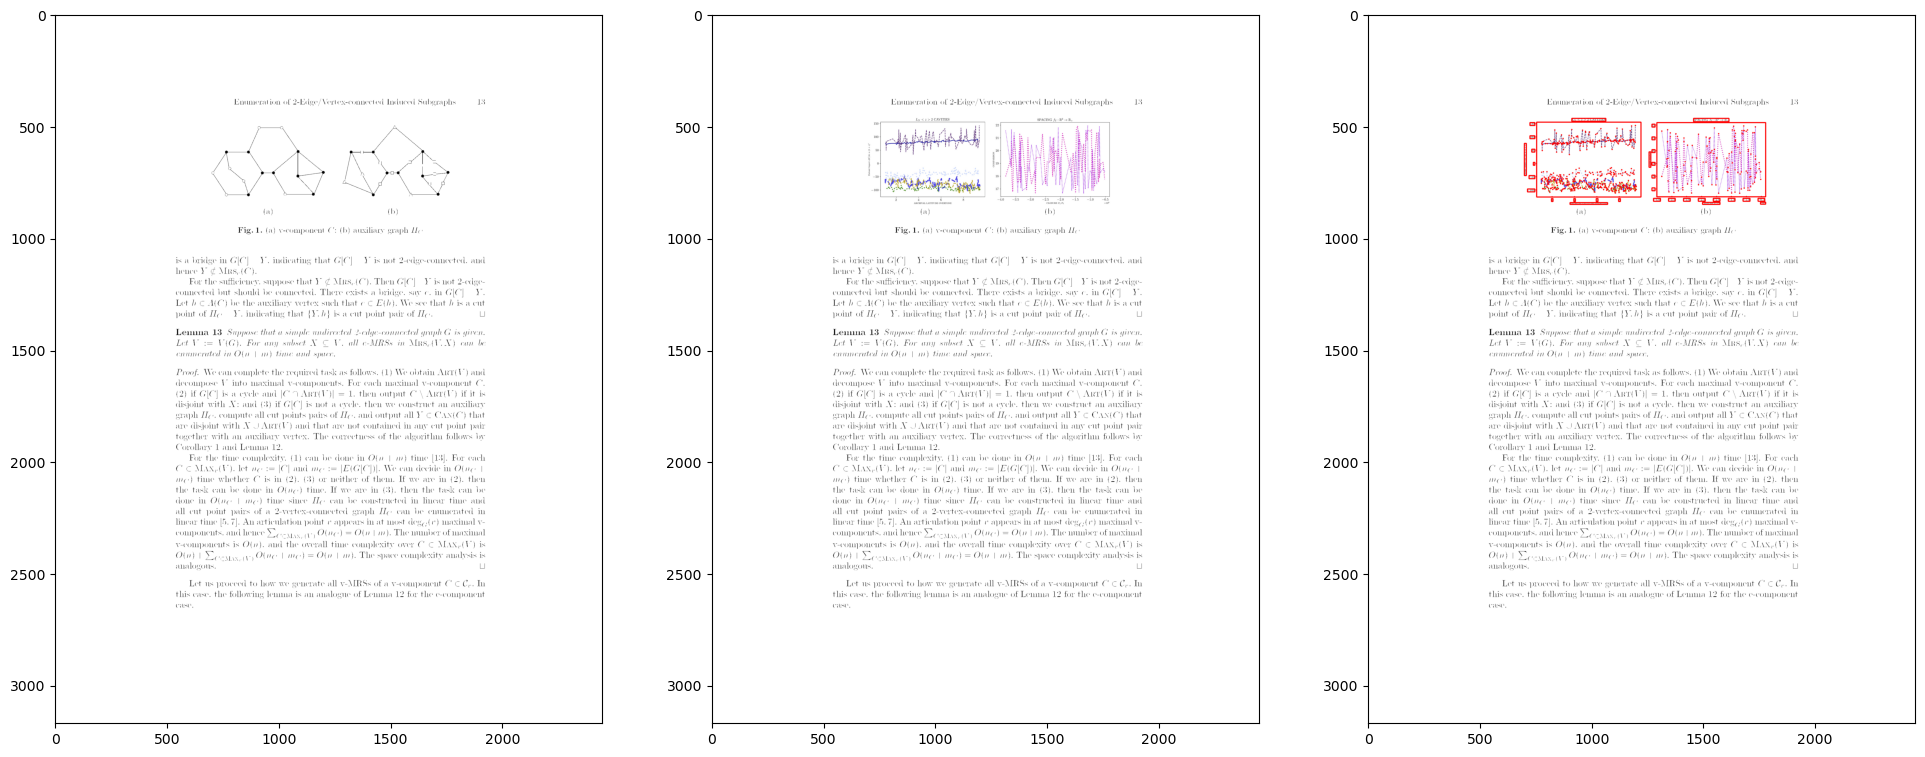

In [41]:
import utils.translation_utils
reload(utils.translation_utils)
from utils.translation_utils import translate_data
import utils.annotation_utils_translate
reload(utils.annotation_utils_translate)
from utils.annotation_utils_translate import add_annotations

# option -- connect with facecolor?
connect_facecolor_prob = 0.5 # probablity of connecting

# open each
nfig = 3
plt.style.use('default')
fig, ax = plt.subplots(1,nfig, figsize=(8*nfig, 11.5))

img_orig = beginner+d['tex name'].values[0] + '_p'+str(d['page num'].values[0])
with Image.open(tmp_dir + img_orig + '.tiff').convert('RGB') as img_in:
    img_orig = np.array(img_in)   
ax[0].imshow(img_orig)

img_new = img_orig.copy()

for fboxname, figure_box in figure_boxes.items():
    main_fig_num = int(fboxname.split('figure')[-1])-1
    # load images
    main_fig_num = 0 # number on page

    figure_name = str(d['article'].values[0]) + '_page' + str(d['page num'].values[0]).zfill(4) + \
        '_figure' + str(main_fig_num).zfill(3) + '_subfig' + str(0).zfill(4) # just take "base" subfig
    # read in a figure to get facecolor
    with open(fake_figs_dir+'jsons/' + figure_name + '.json','r') as f:
        data = json.load(f)
        data = json.loads(data)

    # set background to facecolor
    box = d['boxes'].values[0]['figure '+str(main_fig_num+1)]
    if np.random.random() <= connect_facecolor_prob:
        #print('yes, connect facecolor')
        xmin,ymin,xmax,ymax = int(round(box['xmin'])),int(round(box['ymin'])),int(round(box['xmax'])),int(round(box['ymax']))
        facecolor = np.array(data['figure']['facecolor'])
        if np.array(data['figure']['facecolor']).dtype == 'float' and img_new.dtype == 'uint8':
            facecolor = np.round(facecolor*255).astype('uint8')[:3]
        img_new[ymax:ymin,xmin:xmax,:] = facecolor


    boxes = d['boxes'].values[0]['figure '+str(main_fig_num+1)]
    for subfigNum, subparams in subfig_params.items():
        print('******** ON SUBFIG', subfigNum+1, 'of', nsubfigs, '************')
        box = boxes['subfig ' + str(subfigNum)]
        figure_name = str(d['article'].values[0]) + '_page' + str(d['page num'].values[0]).zfill(4) + \
            '_figure' + str(main_fig_num).zfill(3) + '_subfig' + str(subfigNum).zfill(4)
        with Image.open(fake_figs_dir + 'imgs/'+figure_name + '.jpeg') as img:
            # resize
            h,w = box['ymin']-box['ymax'], box['xmax']-box['xmin']
            new_size = (int(round(w)),int(round(h)))
            resized_img = img.resize(new_size, Image.Resampling.LANCZOS)
            img_in = np.array(resized_img)
            # place
            xmin,ymin,xmax,ymax = int(round(box['xmin'])),int(round(box['ymin'])),int(round(box['xmax'])),int(round(box['ymax']))
            img_new[ymax:ymin,xmin:xmax] = img_in
ax[1].imshow(img_new)


# update with boxes
img_boxes = img_new.copy()
for fboxname, figure_box in figure_boxes.items():
    main_fig_num = int(fboxname.split('figure')[-1])-1
    # load images
    main_fig_num = 0 # number on page

    # bounding box for new fig
    box = d['boxes'].values[0]['figure '+str(main_fig_num+1)]
    # xmin,ymin = int(round(box['xmin'])),int(round(img_boxes.shape[0]-box['ymin']))
    # xmax,ymax = int(round(box['xmax'])),int(round(img_boxes.shape[0]-box['ymax']))
    # xmin,ymin,xmax,ymax = int(round(box['xmin'])),int(round(box['ymin'])),int(round(box['xmax'])),int(round(box['ymax']))
    # #new_canvas = (xmin,ymin,xmax,ymax)
    # new_canvas = (xmin,ymax,xmax,ymin)

    for subfigNum, subparams in subfig_params.items():
        figure_name = str(d['article'].values[0]) + '_page' + str(d['page num'].values[0]).zfill(4) + \
            '_figure' + str(main_fig_num).zfill(3) + '_subfig' + str(subfigNum).zfill(4) # just take "base" subfig
        # read in a figure to get facecolor
        with open(fake_figs_dir+'jsons/' + figure_name + '.json','r') as f:
            data = json.load(f)
            data = json.loads(data)

        bs = boxes['subfig ' + str(subfigNum)]
        datatr = translate_data(data, bs, plot_num=0, roundit=False) # plot_num = 0 for all because putting each figure generated separately in
        img_boxes = add_annotations(deepcopy(img_boxes), deepcopy(datatr), verbose=False, csize=3, flip_ycoord=False)

        # xmin,ymin = int(round(bs['xmin'])),int(round(img_new.shape[0]-bs['ymin']))
        # xmax,ymax = int(round(bs['xmax'])),int(round(img_new.shape[0]-bs['ymax']))
        # new_canvas = (xmin,ymin,xmax,ymax)
        # img_boxes = add_annotations(img_boxes, deepcopy(data), verbose=False, csize=15, new_canvas = new_canvas)

ax[2].imshow(img_boxes)

In [ ]:
#datatr['plot0']['data pixels']['ys']

[567.7194416046784,
 605.645955856502,
 566.5568645672905,
 564.5653618426697,
 554.555460261284,
 575.0772494009022,
 556.768218489068,
 573.1535232297261,
 513.6315968482568,
 595.8822956947164,
 581.5433818555043,
 573.2397943476274,
 528.117552934114,
 612.6891567136529,
 571.1057692492789,
 580.4850369396747,
 563.8985147678335,
 536.4342343137495,
 579.2757223687219,
 613.0222089436542,
 551.6438106709511,
 601.8732502162243,
 577.5818038568208,
 537.5172369090845,
 624.1777463921942,
 565.6283168727311,
 571.1977383516048,
 552.4723961849023,
 511.6702404446461,
 541.1129130657733,
 548.675036034237,
 569.4339176562842,
 543.4745937038904,
 541.0203536823004,
 545.7519722361748,
 569.9648132844716,
 606.1771461735127,
 584.9724299028006,
 515.4517954821689,
 587.2152439578987,
 520.0654018094988,
 523.8750343120133,
 601.596980424252,
 585.896776649583,
 535.1023085165905,
 522.8777776733434,
 523.4486249578943,
 558.9578039973073,
 572.6818610238398,
 558.9005191933821,
 590.12

In [36]:
ys = data['plot0']['data pixels']['ys']
xs = data['plot0']['data pixels']['xs']

In [37]:
for xx,yy in zip(xs,ys):
    for x,y in zip(xx,yy):
        print(x,y)

234.91718069674272 833.5601430308349
235.57722308713437 891.3848554740218
238.82610573710036 837.5243402161234
276.29433272323945 871.6990416997394
307.8658823574077 928.4646713036316
317.3767660027128 903.5674827250119
326.29948650010164 863.5867061457022
330.5779532842695 892.3549576954206
333.7512886870286 836.3578865102775
334.116637614764 901.2472019818604
343.9112540229027 872.6850834714497
359.0989921310485 838.7066102423536
376.8039806453458 861.021882054645
413.3415875143426 852.386305933069
420.8586749918431 827.391483557305
425.0812794652618 845.3997485987802
436.2277223222444 871.4693925594087
444.9558126647856 873.9007180941957
454.163218216357 826.6822606187875
479.6073877799481 849.0437498879731
485.84191453766357 836.6018052746423
498.1579142232092 792.1004765172218
513.092240825336 844.2015749456152
540.1740380623353 882.4685357444337
555.9574833176113 955.8784930915434
591.3717290432884 905.195672545397
591.6951097269343 879.6696507693933
592.8825280469621 854.6623947